In [2]:
# ==========================================================
# BLOQUE 1: IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip -q install tensorflow # instalamos librerias para hacer mlp de tf
!pip -q install keras


print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
# ==========================================================
# BLOQUE 2: CARGA DEL DATASET
# ==========================================================

df = pd.read_csv("/Rice_MSC_Dataset.csv")
print("Dataset cargado correctamente")

Dataset cargado correctamente


In [20]:
# ==========================================================
# BLOQUE 2.1:Eliminar valores Null
# ==========================================================

df = df.fillna(df.mean(numeric_only=True))

print("Valores nulos restantes:", df.isnull().sum().sum())

Valores nulos restantes: 0


In [21]:
# ==========================================================
# BLOQUE 3: Explorando dataset
# ==========================================================

df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,ALLdaub4L,ALLdaub4a,ALLdaub4b,ALLdaub4Y,ALLdaub4Cb,ALLdaub4Cr,ALLdaub4XX,ALLdaub4YY,ALLdaub4ZZ,CLASS
0,7805,437.915,209.8215,48.0221,0.9735,99.6877,0.9775,7985,0.3547,4.3693,...,113.9924,65.0610,59.5989,104.8552,67.8779,63.0828,0.3673,0.3793,0.4733,Basmati
1,7503,340.757,138.3361,69.8417,0.8632,97.7400,0.9660,7767,0.6637,1.9807,...,105.7055,64.3685,62.2084,96.8375,65.5371,63.5832,0.3014,0.3144,0.3641,Arborio
2,5124,314.617,141.9803,46.5784,0.9447,80.7718,0.9721,5271,0.4760,3.0482,...,109.7155,62.6423,58.7439,100.2352,68.9753,59.8342,0.3233,0.3445,0.4448,Jasmine
3,7990,437.085,201.4386,51.2245,0.9671,100.8622,0.9659,8272,0.6274,3.9325,...,116.5405,64.9069,60.2562,107.2560,67.3298,63.2237,0.3880,0.4020,0.4904,Basmati
4,7433,342.893,140.3350,68.3927,0.8732,97.2830,0.9831,7561,0.6006,2.0519,...,107.7502,64.7071,61.3549,98.8704,66.2048,63.5378,0.3184,0.3303,0.3928,Arborio


In [22]:
# ==========================================================
# BLOQUE 4: INFORMACIÓN GENERAL DEL DATASET
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Columns: 107 entries, AREA to CLASS
dtypes: float64(95), int64(11), object(1)
memory usage: 61.2+ MB


In [23]:
# ==========================================================
# BLOQUE 5: ESTADÍSTICAS DESCRIPTIVAS
# ==========================================================

df.describe()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,ALLdaub4V,ALLdaub4L,ALLdaub4a,ALLdaub4b,ALLdaub4Y,ALLdaub4Cb,ALLdaub4Cr,ALLdaub4XX,ALLdaub4YY,ALLdaub4ZZ
count,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,...,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000
mean,8379.197507,378.169453,161.805540,66.829335,0.886077,101.731251,0.975896,8584.862320,0.633226,2.597063,...,0.448960,111.088252,64.379443,61.461457,101.925425,66.240541,63.202088,0.341944,0.357058,0.421176
std,3119.209274,70.597008,36.461005,16.689269,0.071906,17.874070,0.007966,3189.298025,0.123795,0.968982,...,0.021736,5.904854,1.175616,2.435635,5.436861,2.159109,1.174976,0.041921,0.047139,0.043137
min,3929.000000,261.040000,96.968300,34.673000,0.627700,70.728800,0.877500,4032.000000,0.278800,1.284500,...,0.313900,82.300600,59.137900,53.653800,75.191800,58.323800,57.363400,0.159700,0.169000,0.191800
25%,6259.000000,316.431500,132.623500,49.650200,0.846100,89.270400,0.970900,6385.000000,0.561000,1.876100,...,0.434200,106.632900,63.883800,59.465575,97.834400,64.842000,63.052800,0.309900,0.320900,0.391200
50%,7345.000000,351.261000,149.343950,69.183900,0.885600,96.705500,0.976400,7532.000000,0.655800,2.153200,...,0.451600,110.770700,64.419350,61.424400,101.683700,66.291600,63.522050,0.340100,0.353300,0.424200
75%,8901.000000,444.986000,197.462025,75.814125,0.950800,106.457100,0.982200,9153.000000,0.727800,3.228700,...,0.466100,115.065075,65.174200,63.076825,105.592450,68.011800,63.734000,0.370300,0.387900,0.454700
max,21019.000000,593.698000,255.647200,113.441100,0.986800,163.591600,0.992100,21633.000000,0.901700,6.179500,...,0.495100,126.265100,67.459000,70.284000,116.287300,73.424700,66.539100,0.463900,0.488600,0.530200


In [24]:
# ==========================================================
# BLOQUE 5: DISTRIBUCIÓN DE LAS CLASES
# ==========================================================


df['CLASS'].value_counts()


,count
CLASS,
Basmati,15000
Arborio,15000
Jasmine,15000
Ipsala,15000
Karacadag,15000


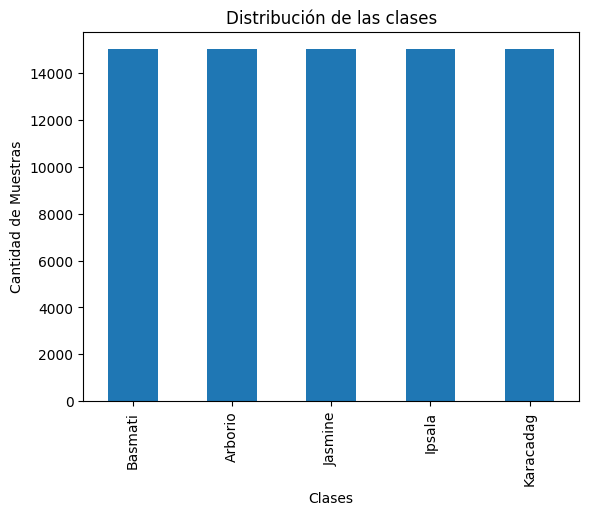

In [25]:
# ==========================================================
# BLOQUE 6: GRÁFICA DE DISTRIBUCIÓN DE LAS CLASES
# ==========================================================

df['CLASS'].value_counts().plot(kind='bar')

# ==========================================================
# Organizamos los datos en la grarfica
# ==========================================================

plt.title('Distribución de las clases')
plt.xlabel('Clases')
plt.ylabel('Cantidad de Muestras')

plt.show()






In [26]:
# ==========================================================
# BLOQUE 7: SEPARACIÓN DE VARIABLES
# ==========================================================

x = df.drop('CLASS',axis=1)
y = df['CLASS']

print("Variables independientes: ", x.shape)
print("Variable Objetivo : ", y.shape)


Variables independientes:  (75000, 106)
Variable Objetivo :  (75000,)


In [27]:
# ==========================================================
# BLOQUE 8: CODIFICACIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y[:100]) # Estos son los 10 primeros registros del vector y(Objertivo),
              # Codificado en numeros con libreria LabelEncoder

[1 0 3 1 0 2 1 0 3 4 3 0 1 4 1 4 4 4 3 2 3 2 2 1 0 3 0 4 2 2 2 1 4 4 3 0 0
 3 3 2 0 2 0 2 3 0 2 4 1 2 1 3 1 2 4 1 3 2 2 2 2 2 0 0 2 4 4 4 3 0 2 0 3 3
 0 3 3 1 2 1 1 3 4 2 4 0 4 1 3 4 3 0 2 4 3 4 3 0 4 4]


In [28]:
# ==========================================================
# BLOQUE 9: NORMALIZACIÓN
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = scaler.fit_transform(x)

print("Datos normalizados correctamente.")

Datos normalizados correctamente.


In [30]:
# ==========================================================
# BLOQUE 10: TRAIN / VALIDATION / TEST
# ==========================================================

from sklearn.model_selection import train_test_split

x_train, x_temp, y_train,y_temp = train_test_split(
    x, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

x_validation, x_test, y_validation, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("Datos para Entrenamiento: ", x_train.shape)
print("Datos para validar: " ,x_validation.shape)
print("Datos a Evaluar: " ,x_test.shape)




Datos para Entrenamiento:  (52500, 106)
Datos para validar:  (11250, 106)
Datos a Evaluar:  (11250, 106)


In [15]:
# ==========================================================

# BLOQUE 13.1: ENTRENAMIENTO DEL MODELO (Corrigiendo Valores Null)

# ==========================================================

import numpy as np

print("NaN en y:", np.isnan(y).sum()) #El siguiente diagnostico ,

print(df.isnull().sum().sum()) #arroja 22 valores en nulo

# Buscando en los valores NaN en las columnas\

df.isnull().sum()[df.isnull().sum() > 0]

# ==========================================================

# BLOQUE 11B: IMPUTACIÓN DE VALORES NULOS

# ==========================================================

print("NaN en X:", np.isnan(x).sum())

print("Inf en X:", np.isinf(x).sum())

df = df.fillna(df.mean(numeric_only=True))

print("Valores nulos restantes:", df.isnull().sum().sum())

NaN en y: 0
0
NaN en X: 22
Inf en X: 0
Valores nulos restantes: 0


In [31]:
# ==========================================================
# BLOQUE 11: CONSTRUCCIÓN DE LA RED NEURONAL MLP
# ==========================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([

    Dense(128, activation='relu', input_shape=(106,)),

    Dense(64, activation='relu'),

    Dense(5, activation='softmax')

])

model.summary()





/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        13,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,277 (87.02 KB)

 Trainable params: 22,277 (87.02 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ==========================================================
# BLOQUE 12: COMPILACIÓN DEL MODELO
# ==========================================================

model.compile(
    optimizer='adam', #Adam es uno de los optimizadores más eficientes,
                      #y utilizados para entrenar redes neuronales profundas.

    loss='sparse_categorical_crossentropy', # Clasificador de Multicapas
    metrics=['accuracy']
)

print("Modelo compilado correctamente.")


Modelo compilado correctamente.


In [33]:


# ==========================================================
# BLOQUE 13: ENTRENAMIENTO DEL MODELO
# ==========================================================

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9941 - loss: 0.0208 - val_accuracy: 0.9974 - val_loss: 0.0091
Epoch 2/20
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9982 - loss: 0.0062 - val_accuracy: 0.9984 - val_loss: 0.0070
Epoch 3/20
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9985 - loss: 0.0048 - val_accuracy: 0.9990 - val_loss: 0.0046
Epoch 4/20
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9986 - loss: 0.0051 - val_accuracy: 0.9964 - val_loss: 0.0113
Epoch 5/20
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9986 - loss: 0.0041 - val_accuracy: 0.9972 - val_loss: 0.0097
Epoch 6/20
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9987 - loss: 0.0036 - val_accuracy: 0.9988 - val_loss: 0.0065
Epoch 7/20
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9988 - loss: 0.0037 - val_accuracy: 0.9983 - val_loss: 0.0070
Epoch 8/20
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9990 - loss: 0.0031 - 

In [35]:
# ==========================================================
# BLOQUE 15: PREDICCIONES
# ==========================================================

import numpy as np

y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)

352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [36]:
# ==========================================================
# BLOQUE 16: REPORTE DE CLASIFICACIÓN
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes,
                            target_names=encoder.classes_))

              precision    recall  f1-score   support

     Arborio       1.00      1.00      1.00      2250
     Basmati       1.00      1.00      1.00      2250
      Ipsala       1.00      1.00      1.00      2250
     Jasmine       1.00      1.00      1.00      2250
   Karacadag       1.00      1.00      1.00      2250

    accuracy                           1.00     11250
   macro avg       1.00      1.00      1.00     11250
weighted avg       1.00      1.00      1.00     11250



<Axes: >

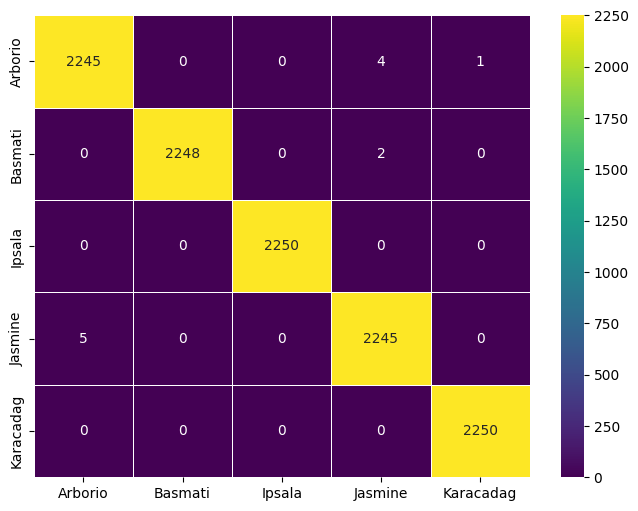

In [53]:
# ==========================================================
# BLOQUE 17: MATRIZ DE CONFUSIÓN
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap='viridis',
    linewidths=0.5,
    linecolor="white",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
